# Классификация Oxford Pets

Обучим сеть для классификации исходного датасета [Oxford-IIIT Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). Загрузите датасет с Kaggle.

In [1]:
# Получаем датасет
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!tar xfz images.tar.gz
!tar xfz annotations.tar.gz
!rm images.tar.gz annotations.tar.gz

--2026-04-22 16:22:41--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-04-22 16:22:42--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  21.8MB/s    in 37s     

2026-04-22 16:23:20 (20.3 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2026-04-22 16:23:20--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.r

In [2]:
!ls annotations
!cat annotations/README

list.txt  README  test.txt  trainval.txt  trimaps  xmls
OXFORD-IIIT PET Dataset
-----------------------
Omkar M Parkhi, Andrea Vedaldi, Andrew Zisserman and C. V. Jawahar

We have created a 37 category pet dataset with roughly 200 images for each class. 
The images have a large variations in scale, pose and lighting. All images have an 
associated ground truth annotation of breed, head ROI, and pixel
level trimap segmentation.

Contents:
--------
trimaps/ 	Trimap annotations for every image in the dataset
		Pixel Annotations: 1: Foreground 2:Background 3: Not classified
xmls/		Head bounding box annotations in PASCAL VOC Format

list.txt	Combined list of all images in the dataset
		Each entry in the file is of following nature:
		Image CLASS-ID SPECIES BREED ID
		ID: 1:37 Class ids
		SPECIES: 1:Cat 2:Dog
		BREED ID: 1-25:Cat 1:12:Dog
		All images with 1st letter as captial are cat images while
		images with small first letter are dog images.
trainval.txt	Files describing splits used in 

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from PIL import Image
from sklearn.metrics import confusion_matrix, accuracy_score
import cv2
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# Загрузка меток из аннотаций

In [6]:
def load_labels():
    labels = {}
    with open('annotations/trainval.txt', 'r') as f:
        for line in f:
            parts = line.strip().split()
            img_name = parts[0]
            breed_id = int(parts[1]) - 1  # 0-based
            species = 1 if parts[2] == '1' else 0  # 0=dog, 1=cat
            labels[img_name] = {'breed': breed_id, 'species': species}
    return labels

labels = load_labels()
num_breeds = max([l['breed'] for l in labels.values()]) + 1
print(labels['Abyssinian_116'])
print(f'Number of breeds: {num_breeds}')

{'breed': 0, 'species': 1}
Number of breeds: 37


# Датасет с аугментацией

In [7]:

class OxfordPetsDataset(Dataset):
    def __init__(self, img_names, labels, transform=None):
        self.img_names = img_names
        self.labels = labels
        self.transform = transform
        self.img_dir = 'images'

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, f'{img_name}.jpg')

        image = Image.open(img_path).convert('RGB')
        breed_label = self.labels[img_name]['breed']
        species_label = self.labels[img_name]['species']

        if self.transform:
            image = self.transform(image)

        return image, breed_label, species_label


img_names = list(labels.keys())
breeds = [labels[n]['breed'] for n in img_names]

train_names, test_names = train_test_split(
    img_names, test_size=0.2, random_state=42, stratify=breeds
)

# Трансформации
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = OxfordPetsDataset(train_names, labels, train_transform)
test_dataset = OxfordPetsDataset(test_names, labels, test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)


# Функция обучения модели

In [8]:
def train_model(model, criterion_breed, criterion_species, optimizer, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, breed_labels, species_labels in train_loader:
            images = images.to(device)
            breed_labels = breed_labels.to(device)
            species_labels = species_labels.to(device)

            optimizer.zero_grad()
            breed_out, species_out = model(images)

            loss = criterion_breed(breed_out, breed_labels) + criterion_species(species_out, species_labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}')

# Функция оценки
def evaluate_model(model):
    model.eval()
    all_breed_preds = []
    all_breed_labels = []
    all_species_preds = []
    all_species_labels = []

    with torch.no_grad():
        for images, breed_labels, species_labels in test_loader:
            images = images.to(device)
            breed_out, species_out = model(images)

            _, breed_preds = torch.max(breed_out, 1)
            _, species_preds = torch.max(species_out, 1)

            all_breed_preds.extend(breed_preds.cpu().numpy())
            all_breed_labels.extend(breed_labels.numpy())
            all_species_preds.extend(species_preds.cpu().numpy())
            all_species_labels.extend(species_labels.numpy())

    breed_acc = accuracy_score(all_breed_labels, all_breed_preds)
    species_acc = accuracy_score(all_species_labels, all_species_preds)

    return breed_acc, species_acc, all_breed_labels, all_breed_preds, all_species_labels, all_species_preds


In [9]:
# Модель на основе VGG16
class VGG16Classifier(nn.Module):
    def __init__(self, num_breeds):
        super().__init__()
        self.backbone = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        for param in self.backbone.parameters():
            param.requires_grad = False

        self.backbone.classifier[6] = nn.Identity()
        self.breed_head = nn.Linear(4096, num_breeds)
        self.species_head = nn.Linear(4096, 2)

    def forward(self, x):
        features = self.backbone(x)
        breed = self.breed_head(features)
        species = self.species_head(features)
        return breed, species

# Модель на основе ResNet50
class ResNet50Classifier(nn.Module):
    def __init__(self, num_breeds):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        for param in self.backbone.parameters():
            param.requires_grad = False

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.breed_head = nn.Linear(in_features, num_breeds)
        self.species_head = nn.Linear(in_features, 2)

    def forward(self, x):
        features = self.backbone(x)
        breed = self.breed_head(features)
        species = self.species_head(features)
        return breed, species

# Обучение VGG16
print("Training VGG16...")
vgg_model = VGG16Classifier(num_breeds).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg_model.parameters(), lr=0.001)
train_model(vgg_model, criterion, criterion, optimizer, num_epochs=10)
vgg_breed_acc, vgg_species_acc, _, _, _, _ = evaluate_model(vgg_model)
print(f'VGG16 - Breed Acc: {vgg_breed_acc:.4f}, Species Acc: {vgg_species_acc:.4f}')

# Обучение ResNet50
print("\nTraining ResNet50...")
resnet_model = ResNet50Classifier(num_breeds).to(device)
optimizer = optim.Adam(resnet_model.parameters(), lr=0.001)
train_model(resnet_model, criterion, criterion, optimizer, num_epochs=10)
resnet_breed_acc, resnet_species_acc, _, _, _, _ = evaluate_model(resnet_model)
print(f'ResNet50 - Breed Acc: {resnet_breed_acc:.4f}, Species Acc: {resnet_species_acc:.4f}')

# Выбираем лучшую модель (ResNet50)
best_model = resnet_model
print(f"\nBest model: ResNet50 with breed accuracy {resnet_breed_acc:.4f}")


Training VGG16...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 75.8MB/s]


Epoch 1/10, Loss: 0.9637
Epoch 2/10, Loss: 0.3951
Epoch 3/10, Loss: 0.3207
Epoch 4/10, Loss: 0.2818
Epoch 5/10, Loss: 0.2387
Epoch 6/10, Loss: 0.2126
Epoch 7/10, Loss: 0.2174
Epoch 8/10, Loss: 0.1951
Epoch 9/10, Loss: 0.1882
Epoch 10/10, Loss: 0.1902
VGG16 - Breed Acc: 0.9008, Species Acc: 0.9918

Training ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 214MB/s]


Epoch 1/10, Loss: 1.8394
Epoch 2/10, Loss: 0.6076
Epoch 3/10, Loss: 0.4613
Epoch 4/10, Loss: 0.3749
Epoch 5/10, Loss: 0.3338
Epoch 6/10, Loss: 0.2845
Epoch 7/10, Loss: 0.2570
Epoch 8/10, Loss: 0.2375
Epoch 9/10, Loss: 0.2138
Epoch 10/10, Loss: 0.2043
ResNet50 - Breed Acc: 0.9090, Species Acc: 0.9918

Best model: ResNet50 with breed accuracy 0.9090


# Оценка лучшей модели

Breed classification accuracy: 0.9090
Binary (cat/dog) classification accuracy: 0.9918
Top-3 accuracy: 0.9878
Top-5 accuracy: 0.9932


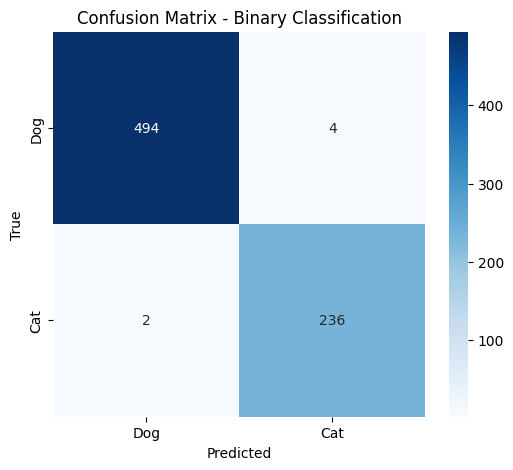

In [10]:
breed_acc, species_acc, breed_labels, breed_preds, species_labels, species_preds = evaluate_model(best_model)

print(f"Breed classification accuracy: {breed_acc:.4f}")
print(f"Binary (cat/dog) classification accuracy: {species_acc:.4f}")

# Top-k accuracy
def top_k_accuracy(model, k=3):
    model.eval()
    top_k_correct = 0
    total = 0
    with torch.no_grad():
        for images, breed_labels, _ in test_loader:
            images = images.to(device)
            breed_out, _ = model(images)
            _, top_k_preds = breed_out.topk(k, 1, True, True)
            top_k_correct += sum([breed_labels[i] in top_k_preds[i] for i in range(len(breed_labels))])
            total += len(breed_labels)
    return top_k_correct / total

top3_acc = top_k_accuracy(best_model, k=3)
top5_acc = top_k_accuracy(best_model, k=5)
print(f"Top-3 accuracy: {top3_acc:.4f}")
print(f"Top-5 accuracy: {top5_acc:.4f}")

# Confusion Matrix для бинарной классификации
cm = confusion_matrix(species_labels, species_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Dog', 'Cat'], yticklabels=['Dog', 'Cat'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Binary Classification')
plt.show()

# GradCam

In [42]:
class GradCam:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, target_class):
        self.model.eval()
        self.model.zero_grad()
        breed_out, _ = self.model(input_image.unsqueeze(0).to(device))
        score = breed_out[0, target_class]
        score.backward()

        #weights = torch.mean(self.gradients[0], dim=(1, 2), keepdim=True)
        if self.gradients is None:
          print("WARNING: gradients is None, trying alternative hook...")
          weights = torch.ones(self.activations[0].shape[0], device=device)
          weights = weights[:, None, None]
        else:
          weights = torch.mean(self.gradients[0], dim=(1, 2), keepdim=True)
        cam = torch.sum(weights * self.activations[0], dim=0)
        cam = torch.relu(cam)
        cam = cam.cpu().detach().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# Выбор 5 изображений и 5 классов для визуализации
test_images = []
test_breeds = []
test_paths = []

for i, name in enumerate(test_names[:10]):
    img_path = f'images/{name}.jpg'
    test_paths.append(img_path)
    test_images.append(transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])(Image.open(img_path).convert('RGB')))
    test_breeds.append(labels[name]['breed'])

selected_images_idx = [0, 1, 2, 3, 4]
selected_classes = [test_breeds[i] for i in selected_images_idx]

# GradCam для последнего сверточного слоя ResNet
target_layer = best_model.backbone.layer4[-1].conv2
# Размораживаем слой, чтобы получить градиенты
for param in best_model.backbone.layer4[-1].conv2.parameters():
    param.requires_grad = True

# Также размораживаем BatchNorm слои в этом блоке
for param in best_model.backbone.layer4[-1].bn2.parameters():
    param.requires_grad = True
grad_cam = GradCam(best_model, target_layer)

fig, axes = plt.subplots(5, 6, figsize=(15, 15))
for i, img_idx in enumerate(selected_images_idx):
    original_img = transforms.ToPILImage()(test_images[img_idx])
    axes[i, 0].imshow(original_img)
    axes[i, 0].set_title(f'Original\nBreed: {test_breeds[img_idx]}')
    axes[i, 0].axis('off')

    for j, target_class in enumerate(selected_classes):
        cam = grad_cam.generate(test_images[img_idx], target_class)
        cam_resized = cv2.resize(cam, (224, 224))

        img_np = test_images[img_idx].permute(1, 2, 0).numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)

        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(np.uint8(255 * img_np), 0.6, heatmap, 0.4, 0)

        axes[i, j+1].imshow(overlay)
        axes[i, j+1].set_title(f'Target: Breed {target_class}')
        axes[i, j+1].axis('off')

plt.suptitle('GradCam Visualizations - Rows: Original Images, Columns: Target Classes')
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [13]:
print("="*50)
print("RESULTS SUMMARY")
print("="*50)
print(f"Best model: ResNet50")
print(f"Breed classification accuracy: {breed_acc:.4f} ({breed_acc*100:.2f}%)")
print(f"Binary classification accuracy (cat/dog): {species_acc:.4f} ({species_acc*100:.2f}%)")
print(f"Top-3 accuracy: {top3_acc:.4f} ({top3_acc*100:.2f}%)")
print(f"Top-5 accuracy: {top5_acc:.4f} ({top5_acc*100:.2f}%)")
print("="*50)

RESULTS SUMMARY
Best model: ResNet50
Breed classification accuracy: 0.9090 (90.90%)
Binary classification accuracy (cat/dog): 0.9918 (99.18%)
Top-3 accuracy: 0.9878 (98.78%)
Top-5 accuracy: 0.9932 (99.32%)
